In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 # type: ignore
import pickle
import re

sys.path.append(".")
from trajectory import World
from Gardner_data_test.Gardner_lifting_test import interpolate_2d_along_axis_0
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat
from affine_transform.score_mismatch import score_mismatch
from constants import TRAJ_PATH, NOISY_DATA_PATH, NOISY_DATA_FIG_PATH

In [3]:
num_holes = 1
traj = pickle.load(open(os.path.join(TRAJ_PATH, f"random_walk_{num_holes}holes.pkl"), "rb"))[0]
# lifted = pickle.load(open(f"grid_fields/world_{num_holes}holes/toroidal_coords_lifted.pkl", "rb"))
lifted = np.loadtxt(os.path.join(NOISY_DATA_PATH, f"toroidal_coords_portion0.005_variance1.csv"), delimiter=",")
print(traj.shape, lifted.shape)


(25000, 2) (599999, 2)


In [4]:
matrix = get_transform_mat(lifted, traj)
recovered_path = apply_transform_mat(lifted, matrix)

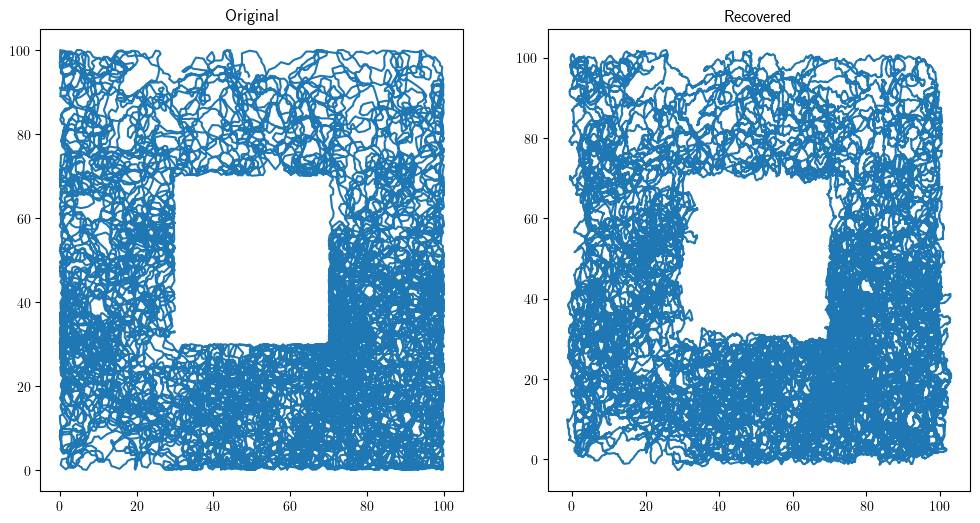

In [5]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.plot(traj[:, 0], traj[:, 1])
plt.title("Original")
plt.subplot(122)
plt.plot(recovered_path[:, 0], recovered_path[:, 1])
plt.title("Recovered")
plt.show()

In [6]:
score_mismatch(traj, recovered_path)

0.015845797852021812

In [7]:
noisy_path = NOISY_DATA_PATH
all_results = os.listdir(noisy_path)
all_results = [x for x in all_results if x.endswith(".csv")]
all_results = [x for x in all_results if "toroidal_coords" in x]
all_results = sorted(all_results, key=lambda x: int(re.findall(r'variance(\d+)', x)[0]))
all_results = sorted(all_results, key=lambda x: float(re.findall(r'portion(\d+\.\d+)', x)[0]))
all_results

['toroidal_coords_portion0.001_variance1.csv',
 'toroidal_coords_portion0.001_variance1_maxnoise0.2.csv',
 'toroidal_coords_portion0.001_variance1_maxnoise0.3.csv',
 'toroidal_coords_portion0.001_variance1_maxnoise0.4.csv',
 'toroidal_coords_portion0.001_variance10.csv',
 'toroidal_coords_portion0.001_variance10_maxnoise0.2.csv',
 'toroidal_coords_portion0.001_variance10_maxnoise0.3.csv',
 'toroidal_coords_portion0.001_variance10_maxnoise0.4.csv',
 'toroidal_coords_portion0.001_variance50.csv',
 'toroidal_coords_portion0.001_variance50_maxnoise0.2.csv',
 'toroidal_coords_portion0.001_variance50_maxnoise0.3.csv',
 'toroidal_coords_portion0.001_variance50_maxnoise0.4.csv',
 'toroidal_coords_portion0.001_variance100.csv',
 'toroidal_coords_portion0.001_variance100_maxnoise0.2.csv',
 'toroidal_coords_portion0.001_variance100_maxnoise0.3.csv',
 'toroidal_coords_portion0.001_variance100_maxnoise0.4.csv',
 'toroidal_coords_portion0.001_variance500.csv',
 'toroidal_coords_portion0.005_variance

In [8]:
traj = pickle.load(open(os.path.join(TRAJ_PATH, f"random_walk_{1}holes.pkl"), "rb"))[0]
df = pd.DataFrame(columns=["portion", "variance", "maxnoise", "score"])
for file in all_results:
    if not 'maxnoise' in file:
        portion, variance = re.findall(r"portion(.*?)_variance(.*?).csv", file)[0]
        maxnoise = 0.08
    else:
        portion, variance, maxnoise = re.findall(r"portion(.*?)_variance(.*?)_maxnoise(.*?).csv", file)[0]
    lifted = np.loadtxt(f"{noisy_path}/{file}", delimiter=",")
    try:
        matrix = get_transform_mat(lifted, traj)
        recovered_path = apply_transform_mat(lifted, matrix)
    except:
        recovered_path = lifted.copy()
    score = score_mismatch(traj, recovered_path)
    print(f"Portion: {portion},\t Variance: {variance},\t max_noise: {maxnoise} Score: {score}")
    df.loc[len(df)] = [float(portion), int(variance), float(maxnoise), score]
df.to_csv(os.path.join(NOISY_DATA_FIG_PATH, '..', "noisy_mismatch.csv"), index=False)

Portion: 0.001,	 Variance: 1,	 max_noise: 0.08 Score: 0.01830725029956574
Portion: 0.001,	 Variance: 1,	 max_noise: 0.2 Score: 0.015358473606320042
Portion: 0.001,	 Variance: 1,	 max_noise: 0.3 Score: 0.01594123466043955
Portion: 0.001,	 Variance: 1,	 max_noise: 0.4 Score: 0.015624459700554089
Portion: 0.001,	 Variance: 10,	 max_noise: 0.08 Score: 0.016157524706472106
Portion: 0.001,	 Variance: 10,	 max_noise: 0.2 Score: 0.015428822358628658
Portion: 0.001,	 Variance: 10,	 max_noise: 0.3 Score: 0.01613815712626257
Portion: 0.001,	 Variance: 10,	 max_noise: 0.4 Score: 0.015502329937827661
Portion: 0.001,	 Variance: 50,	 max_noise: 0.08 Score: 0.016773084085423405
Portion: 0.001,	 Variance: 50,	 max_noise: 0.2 Score: 0.01580348637463219
Portion: 0.001,	 Variance: 50,	 max_noise: 0.3 Score: 0.016389915560038677
Portion: 0.001,	 Variance: 50,	 max_noise: 0.4 Score: 0.01700138046521199
Portion: 0.001,	 Variance: 100,	 max_noise: 0.08 Score: 0.01657715655229336
Portion: 0.001,	 Variance: 100